# First model: Gaussian Mixture

While the end-goal of this project is to have a functioning Hidden Markov Model to capture the temporal behaviour of our crops, it is first necessary for us to establish a baseline model operating under the assumption of statistical independence. The inherent problem of this project is unsupervised, therefore we consider a range of unsupervised models, starting off with clustering.

In [239]:
import sys
from pathlib import Path
import ee

sys.path.append(str(Path.cwd().parent / "src"))
print("Authenticating with Google Earth Engine...")
ee.Authenticate()
print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating with Google Earth Engine...
Initializing project...


In [240]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.mixture import GaussianMixture 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


from data import utils

## Load Data

In [601]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])

spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])

grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])

master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)

In [602]:
# Engineered features
eng_non_spectral_df  = pd.read_csv("../data/processed/eng_non_spectral_df.csv", index_col=0)
eng_non_spectral_df["Timestamp"] = pd.to_datetime(eng_non_spectral_df["Timestamp"])
eng_non_spectral_df["in_season"] = eng_non_spectral_df["in_season"].astype('category')
eng_non_spectral_df["Growth_Stage"] = eng_non_spectral_df["Growth_Stage"].astype('category')

# Rolling statistics and lagged variables
roll_lag_df = pd.read_csv("../data/processed/roll_lag_df.csv", index_col=0)
roll_lag_df["Timestamp"] = pd.to_datetime(roll_lag_df["Timestamp"])


### Extracting Anomaly Data

In [603]:
# Extract extreme drought years 2018, 2019

def get_anomaly_df(df):
    mask = df["Timestamp"].dt.year.isin([2018, 2019])
    return df[~mask].copy(), df[mask].copy()

In [604]:
norm_ns_df, anom_ns_df = get_anomaly_df(non_spectral_df)
norm_s_df, anom_s_df = get_anomaly_df(grouped_spectral_df[["Timestamp", "NDVI_mean", "NDWI_mean", "NDRE_mean"]])

norm_eng_ns_df, anom_eng_ns_df = get_anomaly_df(eng_non_spectral_df)
norm_roll_lag_df, anom_roll_lag_df = get_anomaly_df(roll_lag_df)

---

## Full Model, no lagged variables or rolling statistics

As a simple baseline, we fit a GMM on all our engineered and remaining non-spectral variables. The log likelihood of the training sample will give us a good indication of how well the model fit to the data. Note that, since GMM's assume _continuous_ variables, we do not explicitly make use of the `in_season` or `Growth-Stage` features. We will operate under the assumption that this information is baked into `cummulative_GDD`.

In [605]:
eng_features = [
    'Timestamp',
    'cumulative_GDD', 
    'root_weighted_soil_moisture', 
    'VW_PC1',  
    'Shallow_mean',
    'ST_PC1'

    # Categoricals not included
    #'Growth_Stage',
    #'in_season',
]

non_spectral_features = [
    'Timestamp',
    'temperature_2m',
    'temperature_2m_min',
    'temperature_2m_max', 
    'surface_solar_radiation_downwards_sum',
    'precipitation',
    'volumetric_soil_water_layer_3',
    'volumetric_soil_water_layer_4',
    'soil_temperature_level_4'
]


In [606]:
# Get normal data

X_part1 = norm_eng_ns_df[eng_features]
X_part2 = norm_ns_df[non_spectral_features]
X_non_spectral_norm = pd.merge(X_part2, X_part1, on="Timestamp")
X_norm = X_non_spectral_norm.merge(norm_s_df, on="Timestamp", how="left")
X_norm.head()

,Timestamp,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_4,cumulative_GDD,root_weighted_soil_moisture,VW_PC1,Shallow_mean,ST_PC1,NDVI_mean,NDWI_mean,NDRE_mean
0,2020-01-01,294.218560,289.641174,300.815842,2.342209e+07,5.768824,0.286775,0.267701,292.505906,668.434571,0.323509,1.010358,294.680683,1.862650,NaN,NaN,NaN
1,2020-01-02,294.688144,288.120487,302.366209,2.902789e+07,0.458307,0.286462,0.267696,292.525425,680.527919,0.318876,0.782292,295.221049,2.056825,0.510191,0.162344,0.338149
2,2020-01-03,295.368853,287.284957,302.610221,2.969595e+07,7.398956,0.286025,0.267690,292.546249,692.325508,0.311703,0.427180,295.609568,2.200804,NaN,NaN,NaN
3,2020-01-04,295.601588,288.227640,302.926995,3.014462e+07,12.979295,0.285470,0.267682,292.568757,704.752826,0.304541,0.073355,295.955741,2.330165,NaN,NaN,NaN
4,2020-01-05,295.907643,288.903460,302.875189,3.009218e+07,2.838473,0.284854,0.267672,292.593196,717.492150,0.299192,-0.189093,296.232326,2.435835,NaN,NaN,NaN


### Interpolation

There is a very clear issue here. Due to the fact that **Sentinel-2** only passes a region every few days, we do not have daily spectral readings. These holes in the data are further enlarged by the fact that we drop certain observations through cloud-masking in the data pre-processing step. To keep things simple for now, we will accomadate for this issue with the built-in Cubic Hermit Spline interpolation in `pandas`. 

In [607]:
spectral_columns = ['NDVI_mean', 'NDWI_mean', 'NDRE_mean']
X_norm[spectral_columns] = X_norm[spectral_columns].interpolate(method='pchip', limit_area='inside').bfill()
X_norm[spectral_columns].head(10)

,NDVI_mean,NDWI_mean,NDRE_mean
0,0.510191,0.162344,0.338149
1,0.510191,0.162344,0.338149
2,0.513993,0.168500,0.341483
3,0.517872,0.174706,0.344836
4,0.521828,0.180961,0.348206
5,0.525857,0.187264,0.351595
6,0.529957,0.193613,0.355002
7,0.534126,0.200006,0.358425
8,0.538360,0.206444,0.361864
9,0.542657,0.212923,0.365320


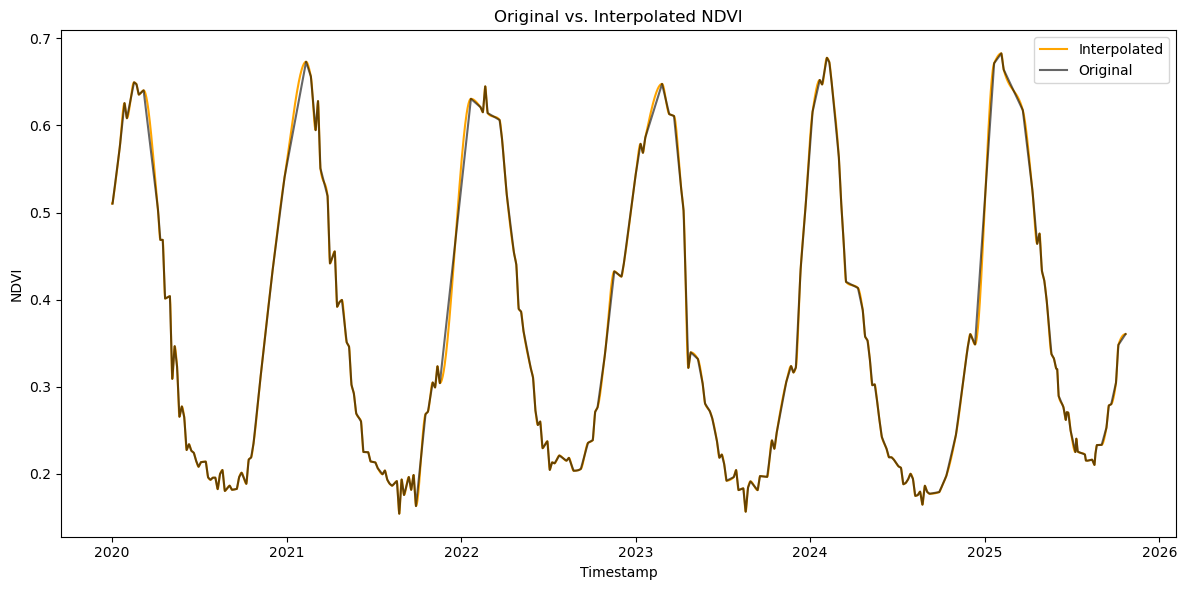

In [608]:
plot_df = utils.merge_with_master(grouped_spectral_df, eng_non_spectral_df)
plot_df, _ = get_anomaly_df(plot_df)

plt.figure(figsize=(12, 6))
plt.title("Original vs. Interpolated NDVI")
plt.plot(X_norm["Timestamp"], X_norm["NDVI_mean"], label="Interpolated", c="orange")
plt.plot(plot_df["Timestamp"], plot_df["NDVI_mean"], label="Original", alpha=0.6, c="black")
plt.xlabel("Timestamp")
plt.ylabel("NDVI")
plt.legend()
plt.tight_layout()
plt.show()

Our biggest issue now is that there are ~95 observations not accounted for at the end of our dataset (due to the same issues as mentioned before). Extrapolation cannot reliably "estimate" 95 days worth of spectral indices. There are however a multitude of other ways we can account for these, from forward-filling to creating a regression model for NDVI. For now, to get to the model-building phase, we will drop these observations. 

In [616]:
X_norm.tail()

,Timestamp,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_4,cumulative_GDD,root_weighted_soil_moisture,VW_PC1,Shallow_mean,ST_PC1,NDVI_mean,NDWI_mean,NDRE_mean
2117,2025-10-18,290.307418,285.935113,295.672774,1.503330e+07,7.262418,0.322494,0.350578,286.845853,0.0,0.0,-0.146324,290.612703,0.242459,0.359621,0.025982,0.237076
2118,2025-10-19,286.427042,282.377030,292.073508,1.564600e+07,7.953155,0.322192,0.350547,286.884666,0.0,0.0,0.490790,289.755591,-0.056132,0.359978,0.021275,0.237818
2119,2025-10-20,284.402085,281.078751,288.024827,1.100849e+07,0.000000,0.322087,0.350523,286.922756,0.0,0.0,1.183680,288.391628,-0.541409,0.360230,0.015715,0.238357
2120,2025-10-21,286.209297,280.610100,293.149290,2.843667e+07,0.000000,0.321753,0.350479,286.957585,0.0,0.0,0.924886,288.978329,-0.353307,0.360379,0.009230,0.238687
2121,2025-10-22,287.814511,278.337125,295.784581,2.997665e+07,0.000000,0.321080,0.350411,286.990019,0.0,0.0,0.626896,289.403314,-0.204881,0.360429,0.001749,0.238799


In [610]:
X_norm = X_norm.dropna()

We apply the same process to the anomaly data:

In [611]:
# Get anomaly data

X_part1 = anom_eng_ns_df[eng_features]
X_part2 = anom_ns_df[non_spectral_features]
X_ns_anom = pd.merge(X_part2, X_part1, on="Timestamp")
X_anom = X_ns_anom.merge(anom_s_df, on="Timestamp", how="left")

X_anom[spectral_columns] = X_anom[spectral_columns].interpolate(method='pchip', limit_area='inside').bfill()
X_anom = X_anom.dropna()
X_anom.head()

,Timestamp,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_4,cumulative_GDD,root_weighted_soil_moisture,VW_PC1,Shallow_mean,ST_PC1,NDVI_mean,NDWI_mean,NDRE_mean
0,2018-01-01,293.314439,284.922923,301.389491,3.288490e+07,0.000000,0.302474,0.270380,290.955942,10.006207,0.0,0.918978,293.879077,1.550109,0.454175,0.15485,0.301027
1,2018-01-02,289.883795,285.298415,295.811490,3.127135e+07,0.000000,0.302010,0.270373,290.987094,17.411159,0.0,0.533468,293.631885,1.465590,0.454175,0.15485,0.301027
2,2018-01-03,290.475579,283.975136,296.656369,2.872766e+07,0.000000,0.301465,0.270366,291.017846,24.576912,0.0,0.244641,293.596234,1.450933,0.454175,0.15485,0.301027
3,2018-01-04,291.254956,283.692780,298.823837,3.154392e+07,2.618651,0.300741,0.270358,291.047929,32.685221,0.0,-0.025467,293.856784,1.541121,0.454175,0.15485,0.301027
4,2018-01-05,293.653434,284.633106,302.508414,3.183471e+07,1.835338,0.299777,0.270349,291.077664,43.105980,0.0,-0.281085,294.420817,1.741368,0.454175,0.15485,0.301027


### Training

Now begins our training process. Expectations for this baseline model are not high due to there not being any consideration for correlation, lagging variables or rolling statistics. 

In [635]:
scaler = StandardScaler()

In [638]:
X = X_norm.drop("Timestamp", axis=1).copy()
X_scaled = scaler.fit_transform(X)
split_i = int(len(X_scaled) * 0.8)

X_train = X_scaled[:split_idx]
X_test = X_scaled[split_idx:]

Xa = X_anom.drop("Timestamp", axis=1).copy()
X_anom_scaled = scaler.fit_transform(Xa)

In [651]:

covariance_types = ['full', 'tied', 'diag', 'spherical']
components = range(1, 50)
bics = np.zeros(shape=(len(covariance_types), len(components)))

min_bic = np.inf
min_bic_k = 0
best_cov = None
best_model = None


for i, cov in enumerate(covariance_types):
    for j, k in enumerate(components):
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
        gmm.fit(X_train)
        bic = gmm.bic(X_train)
        bics[i, j] = bic
        if bic < min_bic:
            min_bic = bic
            min_bic_k = k
            best_cov = cov
            best_model = gmm

print(f"Minimum BIC: {min_bic} with {min_bic_k} components and {best_cov} Covariance Matrices.")

Minimum BIC: -25281.104806636842 with 15 components and full Covariance Matrices.


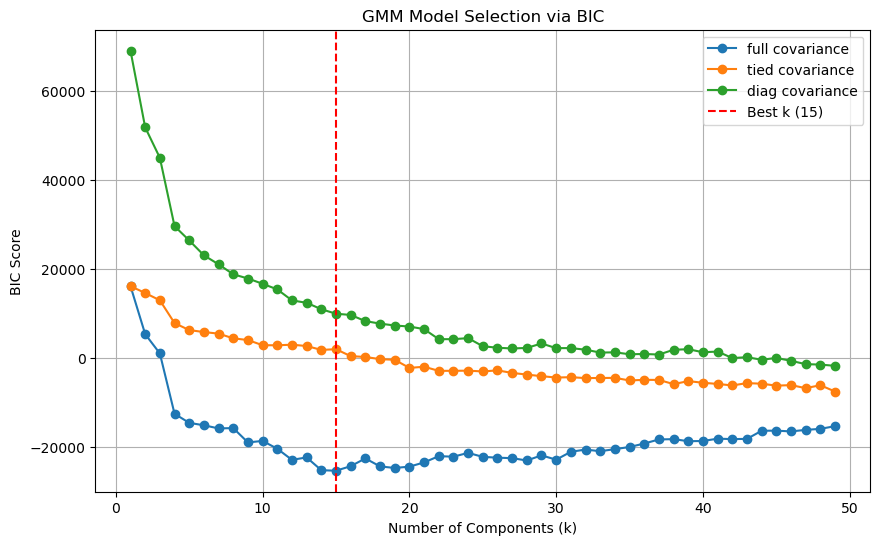

In [652]:
plt.figure(figsize=(10, 6))
for i, cov in enumerate(covariance_types):
    if cov != "spherical":
        plt.plot(components, bics[i], label=f'{cov} covariance', marker='o')

plt.xlabel("Number of Components (k)")
plt.ylabel("BIC Score")
plt.title("GMM Model Selection via BIC")
plt.axvline(x=min_bic_k, color='red', linestyle='--', label=f'Best k ({min_bic_k})')
plt.legend()
plt.grid(True)
plt.show()

In [653]:
test_score = best_model.score(X_test)
anom_score = best_model.score(X_anom_scaled)

print(f"Test data log-likelihood: {test_score}\nAnomaly data log-likelihood: {anom_score}")

Test data log-likelihood: -55.92519319463169
Anomaly data log-likelihood: -122.03674868136824


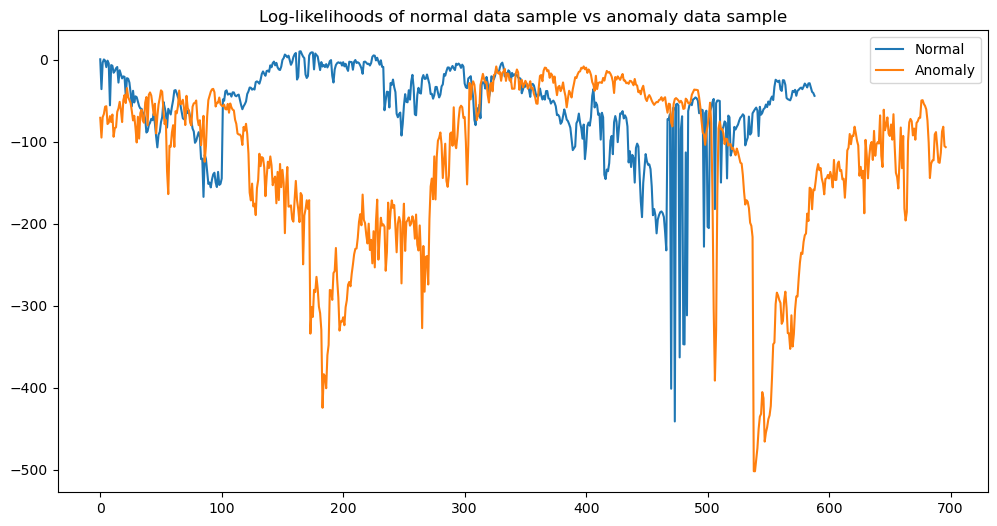

In [663]:
test_scores = best_model.score_samples(X_test)
anom_scores = best_model.score_samples(X_anom_scaled)

plt.figure(figsize=(12, 6))
plt.title("Log-likelihoods of normal data sample vs anomaly data sample")
plt.plot(test_scores, label="Normal")
plt.plot(anom_scores, label="Anomaly")
plt.legend()

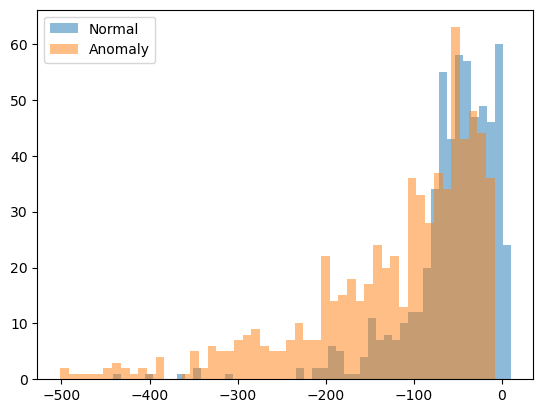

In [660]:
plt.hist(test_scores, bins=50, alpha=0.5, label="Normal")
plt.hist(anom_scores, bins=50, alpha=0.5, label="Anomaly")
plt.legend()

# Rolling Data

In [617]:
roll_lag_features = [
    "Timestamp",
    
    # Temperature
    "temperature_2m_lag_7",
    "temperature_2m_lag_30",
    "temperature_2m_7D_mean",
    "temperature_2m_30D_mean",

    # Solar radiation
    "surface_solar_radiation_downwards_sum_lag_7",
    "surface_solar_radiation_downwards_sum_lag_30",
    "surface_solar_radiation_downwards_sum_7D_sum",
    "surface_solar_radiation_downwards_sum_30D_sum",

    # Precipitation
    "precipitation_lag_7",
    "precipitation_lag_30",
    "precipitation_7D_sum",
    "precipitation_30D_sum",

    # Root-zone soil moisture
    "root_weighted_soil_moisture_lag_7",
    "root_weighted_soil_moisture_lag_30",
    "root_weighted_soil_moisture_7D_mean",
    "root_weighted_soil_moisture_30D_mean",

    # Vegetation indices (PCA components)
    "VW_PC1_lag_7",
    "VW_PC1_lag_30",
    "VW_PC1_7D_mean",
    "VW_PC1_30D_mean",

    # Surface temperature PCA
    "ST_PC1_lag_7",
    "ST_PC1_lag_30",
    "ST_PC1_7D_mean",
    "ST_PC1_30D_mean",

    # Shallow soil moisture
    "Shallow_mean_lag_7",
    "Shallow_mean_lag_30",
    "Shallow_mean_7D_mean",
    "Shallow_mean_30D_mean",

    # Deep volumetric Soil Water Layers
    "volumetric_soil_water_layer_3_7D_mean",
    "volumetric_soil_water_layer_3_30D_mean",
    "volumetric_soil_water_layer_4_7D_mean",
    "volumetric_soil_water_layer_4_30D_mean",
    
    'volumetric_soil_water_layer_3_lag_7',
    'volumetric_soil_water_layer_3_lag_30',
    'volumetric_soil_water_layer_4_lag_7',
    'volumetric_soil_water_layer_4_lag_30',

    # Deep soil temperature layer
    "soil_temperature_level_4_7D_mean",
    "soil_temperature_level_4_30D_mean",
    'soil_temperature_level_4_lag_7',
    'soil_temperature_level_4_lag_30'

]

eng_features = [
    'Timestamp',
    'in_season', 
    'cumulative_GDD', 
    'Growth_Stage',
    'root_weighted_soil_moisture', 
    'VW_PC1', 
    'VW_PC2', 
    'Shallow_mean',
    'ST_PC1'
]
